# Data Mining Project Template (GitHub + Colab)
## Dominic Rueck
## 04/10/2026
## Ethereum Fraud Detection

## Project workflow
This notebook follows an industry-style analytics workflow:

1. **Problem Framing & Data Acquisition**
2. **Exploratory Data Analysis (EDA) & Data Preparation**
3. **Model Development, Evaluation & Business Interpretation**

## GitHub + Colab workflow
1. Create a **new GitHub repository** for your project.
2. Upload this notebook to your repository.
3. In GitHub, open the notebook in **Google Colab**.
4. Commit changes to GitHub as you work.
5. Submit your GitHub repository link when requested.

## Project requirements
- Use a **classification dataset**
- Use **Random Forest** as one of your main models
- Use **Google Colab**
- Include **visualization, preparation, modeling, and interpretation**
- Explain results in a way a manager or stakeholder could understand


In [2]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AutoViz
# !pip install autoviz -q
from autoviz.AutoViz_Class import AutoViz_Class

# scikit-learn tools (Colab-friendly replacement for PyCaret)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report, cohen_kappa_score

# Models to compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


# Project Overview

## 1. Introduction and Problem Statement
As blockchain technology gains mainstream adoption, the Ethereum network has become a primary hub for global decentralized finance. However, as with all financial systems, people try to exploit vulnerabilities for fraudulent gain. Detecting and preventing fraud on the Ethereum blockchain is crucial for maintaining trust and security in the ecosystem.

The core objective of this project is to build a robust classification model capable of differentiating between valid and fraudulent transactions on the Ethereum blockchain. By leveraging historical transaction patterns, I aim to predict the likelihood of fraud, specifically targeting the FLAG variable within our dataset.

## 2. Business Use Case and Impact
This tool could serve as a critical tool for:
- **Financial Institutions & Exchanges**: To automatically flag suspicious transactions or wallets and to protect users from potential losses.
- **Regulatory Bodies**: To monitor and investigate fraudulent activities on the blockchain, ensuring compliance with financial regulations.
- **Individual Users**: To safeguard their assets by identifying potentially fraudulent transactions before they occur.

## 3. Data Acquisition
The data used in this project is sourced from Kaggle, specifically from the <a href="https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset">Ethereum Transaction Dataset for Fraud Detection</a>. This dataset contains a comprehensive collection of Ethereum transactions, labeled as either valid or fraudulent, along with various features that describe the transaction details.

## Motivation
I selected this dataset and problem because of the growing importance of blockchain technology and the critical need for security in decentralized finance. Fraud detection on the Ethereum network is a real-world problem with significant implications for users and institutions alike. By applying data mining techniques to this dataset, I hope to contribute to the development of more secure blockchain systems and to gain practical experience in handling complex, real-world data.



## Data loading options

Choose **one** of the options below:
- load a CSV from GitHub
- upload a CSV into Colab
- read from a direct URL

Keep your original raw data file in your GitHub repository whenever possible.


In [3]:
data_path = "transaction_dataset.csv"
df = pd.read_csv(data_path)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   object 
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841

In [4]:
df.head()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.00,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.0,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.00,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.05,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.00,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.00,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.0,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


# Deliverable 2: Exploratory Data Analysis (EDA) & Data Preparation

## What to include
- basic shape and structure of the data
- variable types
- missing values
- class balance of the target
- visualizations that help explain the data
- preparation steps you used before modeling

## Suggested questions to resolve
- Are there missing values?
- Are the classes balanced?
- Which variables might be useful predictors?
- Are any variables likely to cause problems?
- Do I need to eliminate any variables due to correlation, redundancy, or uniqueness (ex. id)?


In [5]:
# Basic data inspection
print("Shape (rows, columns):", df.shape)
print("\nColumn dtypes (counts):")
print(df.dtypes.value_counts())

id_like = ["Unnamed: 0", "Index", "Address"]
for c in id_like:
    if c in df.columns:
        print(f"  {c}: nunique = {df[c].nunique(dropna=False):,} (rows {len(df):,})")

dup_rows = df.duplicated().sum()
print(f"\nFully duplicate rows: {dup_rows}")

display(df.head())
df.info()
display(df.describe(include="all").T)



Shape (rows, columns): (9841, 51)

Column dtypes (counts):
float64    39
int64       9
object      3
Name: count, dtype: int64
  Unnamed: 0: nunique = 9,841 (rows 9,841)
  Index: nunique = 4,729 (rows 9,841)
  Address: nunique = 9,816 (rows 9,841)

Fully duplicate rows: 0


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.00,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.0,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.00,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.05,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.00,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.00,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.0,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   object 
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,9841.0,NaN,NaN,NaN,4920.0,2840.996333,0.0,2460.0,4920.0,7380.0,9840.0
Index,9841.0,NaN,NaN,NaN,1815.049893,1222.62183,1.0,821.0,1641.0,2601.0,4729.0
Address,9841,9816,0x4cd526aa2db72eb1fd557b37c6b0394acd35b212,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG,9841.0,NaN,NaN,NaN,0.221421,0.415224,0.0,0.0,0.0,0.0,1.0
Avg min between sent tnx,9841.0,NaN,NaN,NaN,5086.878721,21486.549974,0.0,0.0,17.34,565.47,430287.67
Avg min between received tnx,9841.0,NaN,NaN,NaN,8004.851184,23081.714801,0.0,0.0,509.77,5480.39,482175.49
Time Diff between first and last (Mins),9841.0,NaN,NaN,NaN,218333.257652,322937.92574,0.0,316.93,46637.03,304070.98,1954860.95
Sent tnx,9841.0,NaN,NaN,NaN,115.931714,757.226361,0.0,1.0,3.0,11.0,10000.0
Received Tnx,9841.0,NaN,NaN,NaN,163.700945,940.83655,0.0,1.0,4.0,27.0,10000.0
Number of Created Contracts,9841.0,NaN,NaN,NaN,3.729702,141.445583,0.0,0.0,0.0,0.0,9995.0


,missing_n,missing_pct
ERC20 most sent token type,2697,27.41
ERC20_most_rec_token_type,871,8.85
ERC20 min val rec,829,8.42
ERC20 total ether sent,829,8.42
ERC20 total Ether sent contract,829,8.42
ERC20 uniq sent addr,829,8.42
ERC20 uniq rec addr,829,8.42
ERC20 uniq sent addr.1,829,8.42
ERC20 uniq rec contract addr,829,8.42
ERC20 avg time between sent tnx,829,8.42


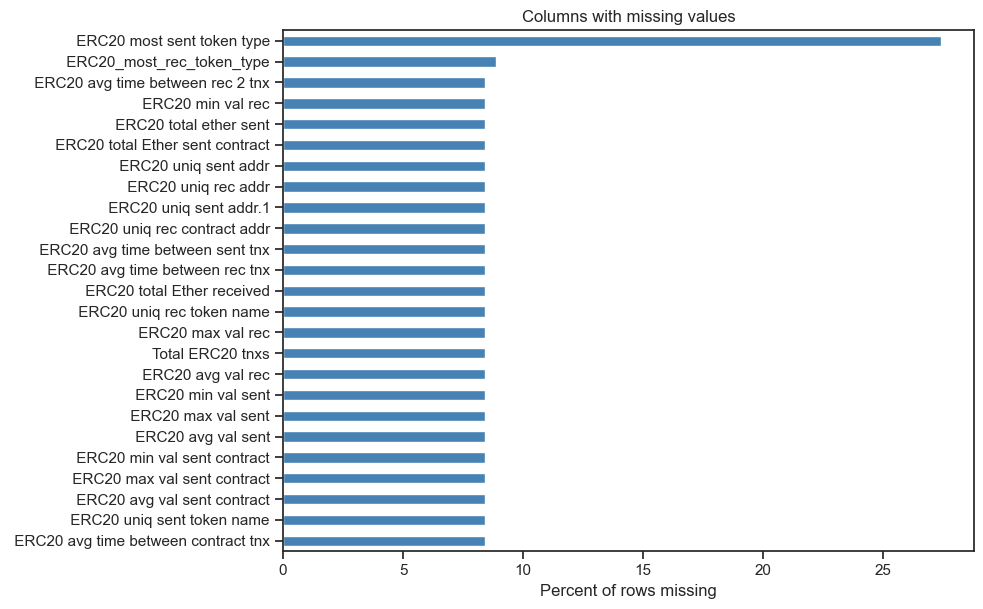

In [6]:
# Missing values
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_tbl = pd.DataFrame({"missing_n": missing_counts, "missing_pct": missing_pct})
display(missing_tbl)

if len(missing_tbl) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, 0.25 * len(missing_tbl))))
    missing_tbl["missing_pct"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Percent of rows missing")
    ax.set_title("Columns with missing values")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")



In [7]:
# Target variable (wallet fraud label)
target = "FLAG"

vc = df[target].value_counts(dropna=False)
prop = df[target].value_counts(normalize=True, dropna=False)
display(vc)
display(prop)

maj_n, min_n = int(vc.max()), int(vc.min())
imb_ratio = maj_n / min_n if min_n else float("nan")
print(f"Imbalance ratio (majority / minority): {imb_ratio:.2f}:1")
print(f"Minority class share: {prop.get(1, prop.get('1', float('nan'))):.2%}")



FLAG
0    7662
1    2179
Name: count, dtype: int64

FLAG
0    0.778579
1    0.221421
Name: proportion, dtype: float64

Imbalance ratio (majority / minority): 3.52:1
Minority class share: 22.14%


The target `FLAG` is **imbalanced**: legitimate-labeled rows are the majority and fraud is the minority (about **22%** fraud in this file, or roughly **3.5:1** majority-to-minority). Accuracy alone can look optimistic while missing fraud, so later modeling emphasizes **precision, recall, F1, and Cohen's kappa**, and we can add class weights or resampling if needed.

Most missingness is concentrated in **ERC-20–related** columns (wallets with no token activity). Those gaps are handled in the modeling pipeline with **imputation** rather than dropping rows, so we keep all labeled addresses.



## Data Visualization

### Class balance and distribution of the target variable

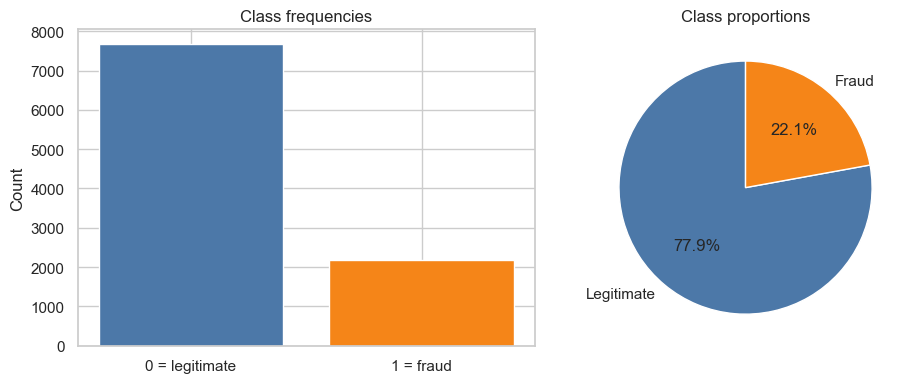

In [ ]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vc = df[target].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=["#4C78A8", "#F58518"])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["0 = legitimate", "1 = fraud"])
axes[0].set_ylabel("Count")
axes[0].set_title("Class frequencies")

axes[1].pie(
    vc.values,
    labels=["Legitimate", "Fraud"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C78A8", "#F58518"],
)
axes[1].set_title("Class proportions")
plt.tight_layout()
plt.show()

### Numeric features only (exclude target); correlations with FLAG

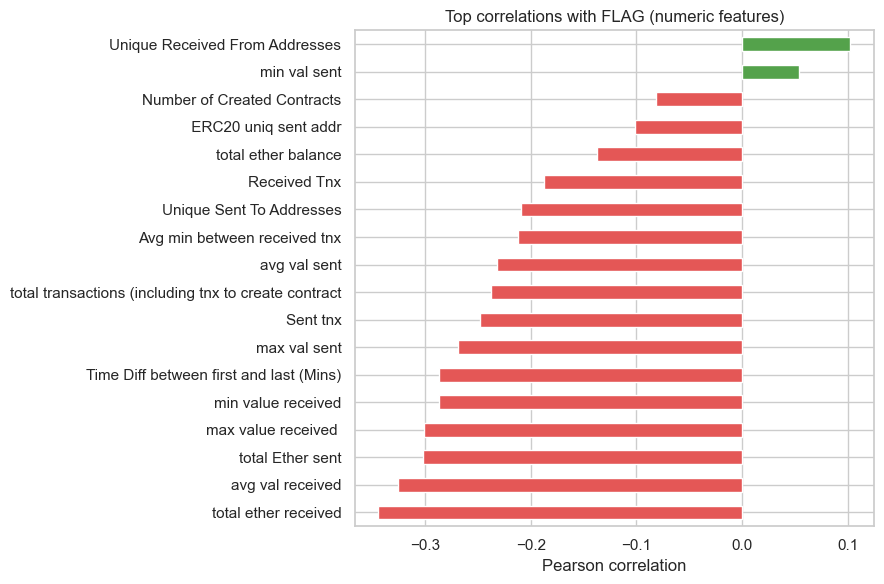

In [ ]:
num_df = df.select_dtypes(include="number").copy()
if target in num_df.columns:
    corr_flag = num_df.corr()[target].drop(labels=[target], errors="ignore")
    corr_flag = corr_flag.dropna()
    corr_flag = corr_flag.loc[corr_flag.abs().sort_values(ascending=False).index].head(18)

    fig, ax = plt.subplots(figsize=(9, 6))
    corr_flag.sort_values().plot(kind="barh", ax=ax, color=np.where(corr_flag.sort_values() < 0, "#E45756", "#54A24B"))
    ax.set_title("Top correlations with FLAG (numeric features)")
    ax.set_xlabel("Pearson correlation")
    plt.tight_layout()
    plt.show()

### Check correlation between all the features

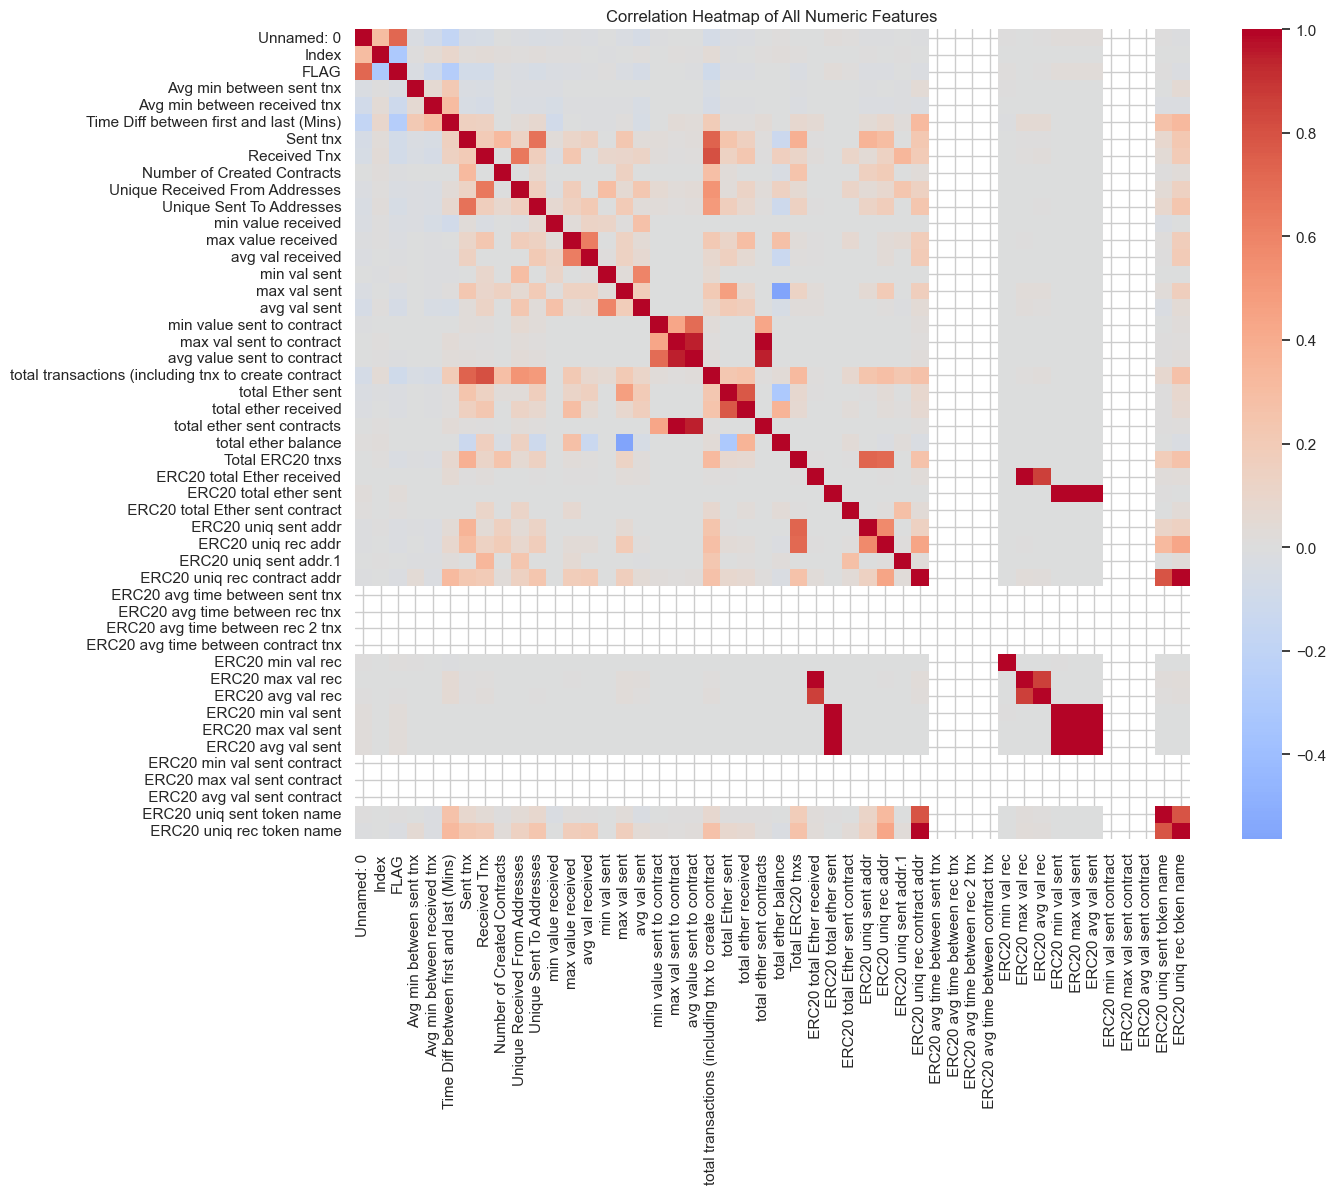

In [ ]:

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of All Numeric Features")
plt.show()

### Data preparation summary

- **Identifiers removed**: `Unnamed: 0`, `Index`, and `Address` were dropped so the model does not use row keys or raw wallet strings (high cardinality, weak legitimate signal for this pipeline).

- **Missing values**: ERC-20 and related fields are often empty when a wallet has no token activity. All rows are kept. **Numeric** columns are filled with the **column median**, and **categorical** columns with the **mode** (or the literal `(missing)` if a column were entirely empty). The sklearn pipeline in the next section still includes imputers so the same modeling code stays valid if anything remains.

- **Outliers**: Extreme values on **numeric feature** columns (not `FLAG`) are **soft-capped** using the **1.5×IQR** rule; when the IQR is zero (near-constant column), values are clipped to the **1st–99th percentiles** instead. This reduces the pull of extreme sends/receives/timing without deleting rare fraud rows.

- **Train / test split**: A **stratified 80/20** split (`random_state=123`) keeps a similar fraud rate in train and test.

- **Feature engineering**: No new derived columns in this milestone; behavior comes from the existing aggregates after cleaning.


## Remove unneeded columns

In [10]:
target = "FLAG"

_drop = [c for c in ["Unnamed: 0", "Index", "Address"] if c in df.columns]
if _drop:
    df = df.drop(columns=_drop)
    print("Dropped columns:", _drop)
else:
    print("No identifier columns found to drop (already removed).")
print("Shape after dropping identifiers:", df.shape)



Dropped columns: ['Unnamed: 0', 'Index', 'Address']
Shape after dropping identifiers: (9841, 48)


## Handle missing values

In [11]:
num_cols = [c for c in df.select_dtypes(include="number").columns if c != target]
cat_cols = [c for c in df.select_dtypes(include=["object", "category", "bool"]).columns]

missing_cells_before = df[num_cols + cat_cols].isna().sum().sum()

for col in num_cols:
    med = df[col].median()
    df[col] = df[col].fillna(med)

for col in cat_cols:
    if df[col].isna().all():
        df[col] = "(missing)"
    else:
        mode_val = df[col].mode(dropna=True)
        fill = mode_val.iloc[0] if len(mode_val) else "(missing)"
        df[col] = df[col].fillna(fill)

missing_cells_after = df[num_cols + cat_cols].isna().sum().sum()
print(f"Missing value cells (features only): {int(missing_cells_before):,} -> {int(missing_cells_after):,}")



Missing value cells (features only): 22,635 -> 0


## Outliers

In [12]:
K_IQR = 1.5
total_clipped = 0
skipped = []

for col in num_cols:
    s = df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        lo, hi = s.quantile(0.01), s.quantile(0.99)
        if pd.isna(lo) or pd.isna(hi) or lo == hi:
            skipped.append(col)
            continue
    else:
        lo, hi = q1 - K_IQR * iqr, q3 + K_IQR * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    total_clipped += n_out
    df[col] = s.clip(lower=lo, upper=hi)

print(f"Numeric outlier treatments: clipped {total_clipped:,} cell values across {len(num_cols)} columns (IQR with percentile fallback).")
if skipped:
    print("Skipped (constant / degenerate):", skipped[:8], "..." if len(skipped) > 8 else "")

print("Final shape:", df.shape)


Numeric outlier treatments: clipped 39,133 cell values across 45 columns (IQR with percentile fallback).
Skipped (constant / degenerate): ['min value sent to contract', 'max val sent to contract', 'avg value sent to contract', 'total ether sent contracts', ' ERC20 total Ether sent contract', ' ERC20 uniq sent addr.1', ' ERC20 avg time between sent tnx', ' ERC20 avg time between rec tnx'] ...
Final shape: (9841, 48)


## Take care of features with a variance of 0

In [13]:
# Check for zero-variance features
zero_var_cols = [col for col in num_cols if df[col].nunique() <= 1]
if zero_var_cols:
    df = df.drop(columns=zero_var_cols)
    print(f"Dropped {len(zero_var_cols)} zero-variance numeric columns:", zero_var_cols[:8], "..." if len(zero_var_cols) > 8 else "")
else:
    print("No zero-variance numeric features detected.")

Dropped 7 zero-variance numeric columns: [' ERC20 avg time between sent tnx', ' ERC20 avg time between rec tnx', ' ERC20 avg time between rec 2 tnx', ' ERC20 avg time between contract tnx', ' ERC20 min val sent contract', ' ERC20 max val sent contract', ' ERC20 avg val sent contract'] 


In [16]:
#ERC20 most sent token type and ERC20_most_rec_token_type are of type object but have very high cardinality (over 100 unique values each) and are unlikely to be useful for modeling, so we will drop them.
drop_cols = []
for col in ["ERC20 most sent token type", "ERC20_most_rec_token_type"]:
    if col in df.columns:
        drop_cols.append(col)

## Display the cleaned dataframe info and head after preparation steps

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 41 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   FLAG                                                  9841 non-null   int64  
 1   Avg min between sent tnx                              9841 non-null   float64
 2   Avg min between received tnx                          9841 non-null   float64
 3   Time Diff between first and last (Mins)               9841 non-null   float64
 4   Sent tnx                                              9841 non-null   int64  
 5   Received Tnx                                          9841 non-null   int64  
 6   Number of Created Contracts                           9841 non-null   int64  
 7   Unique Received From Addresses                        9841 non-null   int64  
 8   Unique Sent To Addresses                              9841

In [19]:
df.head()

,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,844.260,1093.710,704785.630,26,66,0,11,6,0.000000,45.806785,6.589513,0.00,31.220000,1.200681,0.0,0.0,0.0,129,252.158126,248.494364,0.0,-0.065226,5.0,55.37,7.814674e+06,0.0,30.0,5.0,0.0,5.0,0.0,47.513982,33.425,0.000000,2.913074e+06,159706.479300,30.0,5.0,Cofoundit,Numeraire
1,0,1413.675,2958.440,759702.055,26,8,0,5,6,0.000000,2.613269,0.385685,0.00,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,5.0,55.37,2.260809e+00,0.0,1.0,5.0,0.0,5.0,0.0,47.513982,33.425,2.260809,2.260809e+00,2.260809,1.0,5.0,Livepeer Token,Livepeer Token
2,0,1413.675,2434.020,516729.300,2,10,0,10,2,0.113119,1.165453,0.358906,0.05,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,5.0,55.37,0.000000e+00,0.0,0.0,5.0,0.0,5.0,0.0,47.513982,33.425,0.000000,0.000000e+00,0.000000,0.0,5.0,0,XENON
3,0,1413.675,13700.975,397555.900,25,9,0,7,6,0.000000,166.167600,54.359642,0.00,153.554767,54.869174,0.0,0.0,0.0,34,252.158126,248.494364,0.0,-0.065226,5.0,55.37,1.141223e+04,0.0,2.0,5.0,0.0,5.0,0.0,47.513982,33.425,100.000000,9.029231e+03,3804.076893,1.0,5.0,Raiden,XENON
4,0,36.610,10707.770,382472.420,26,20,1,7,6,0.000000,12.802411,2.671095,0.00,9.000000,0.022688,0.0,0.0,0.0,129,104.318883,53.421897,0.0,-0.065226,5.0,55.37,1.235399e+05,0.0,4.0,5.0,0.0,5.0,0.0,47.513982,33.425,0.000000,4.500000e+04,13726.659220,6.0,5.0,StatusNetwork,EOS


In [20]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FLAG,9841.0,NaN,NaN,NaN,0.221421,0.415224,0.0,0.0,0.0,0.0,1.0
Avg min between sent tnx,9841.0,NaN,NaN,NaN,370.353484,577.869376,0.0,0.0,17.34,565.47,1413.675
Avg min between received tnx,9841.0,NaN,NaN,NaN,3498.283942,4999.682546,0.0,0.0,509.77,5480.39,13700.975
Time Diff between first and last (Mins),9841.0,NaN,NaN,NaN,193507.506975,257307.392433,0.0,316.93,46637.03,304070.98,759702.055
Sent tnx,9841.0,NaN,NaN,NaN,7.391119,9.591481,0.0,1.0,3.0,11.0,26.0
Received Tnx,9841.0,NaN,NaN,NaN,18.232598,24.513922,0.0,1.0,4.0,27.0,66.0
Number of Created Contracts,9841.0,NaN,NaN,NaN,0.137791,0.344698,0.0,0.0,0.0,0.0,1.0
Unique Received From Addresses,9841.0,NaN,NaN,NaN,3.744233,3.437438,0.0,1.0,2.0,5.0,11.0
Unique Sent To Addresses,9841.0,NaN,NaN,NaN,2.268773,2.047011,0.0,1.0,2.0,3.0,6.0
min value received,9841.0,NaN,NaN,NaN,1.32791,2.026014,0.0,0.001,0.095856,2.0,4.9985


# Deliverable 3: Model Development, Evaluation & Interpretation

## What to include
- preprocessing pipeline
- Random Forest model
- parameter tuning
- evaluation on the test set
- confusion matrix
- kappa
- feature importance
- interpretation of what the results mean

## Reminder
You should explain results in a business-friendly way, not only with technical language.


In [ ]:
# Modeling imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score
)


In [ ]:
# Identify feature columns
X = df.drop(columns=[target])
y = df[target]

# If needed, convert target labels here
# Example:
# y = y.map({"No": 0, "Yes": 1})

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


In [ ]:
# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)


In [ ]:
# Baseline Random Forest model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("Cohen's Kappa:", round(cohen_kappa_score(y_test, y_pred), 4))


In [ ]:
# Confusion matrix
import matplotlib.pyplot as plt

plt.close('all')
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Random Forest Confusion Matrix")
plt.show()


## Hyperparameter tuning

We do not know the best settings ahead of time, so we try multiple combinations.

A parameter grid gives the model several choices for each setting. GridSearchCV tests combinations and selects the version that performs best according to the scoring metric.


In [ ]:
# Tune the Random Forest model
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


In [ ]:
# Final evaluation on the test set
best_preds = best_rf.predict(X_test)

print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, best_preds))

kappa = cohen_kappa_score(y_test, best_preds)
print("Cohen's Kappa:", round(kappa, 4))


In [ ]:
# Tuned confusion matrix
plt.close('all')
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Tuned Random Forest Confusion Matrix")
plt.show()


## Feature importance

Feature importance helps us see which inputs influenced the Random Forest most.

Be careful:
- importance does **not** prove causation
- importance can be split across multiple one-hot encoded columns
- importance tells us what mattered to the model, not necessarily what matters in the real world


In [ ]:
# Feature importance from the tuned model
import pandas as pd

feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(15))


In [ ]:
# Plot top feature importances
top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Interpretation prompts

Write short answers below:
- How well did the model perform?
- Which class was easier or harder to predict?
- Which variables seemed most important?
- Where did the model make mistakes?
- How could this model be used by a real organization?
- What would you improve next?


### Student interpretation summary
Replace this section with your final written interpretation.


# Optional: Save your final processed data file and model

You may save your trained model if you want to show a deployment-style step.


In [ ]:
import joblib

# Example:
# joblib.dump(best_rf, "final_model.pkl")
# print("Model saved.")

# saving data file
from google.colab import drive
drive.mount('/content/drive')

# Save to Drive
df_clean.to_csv('/content/drive/MyDrive/cleaned_data.csv', index=False)